In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<p style="color:red"></p>


In [2]:
data={'Age':[39,37,40,41,36],'EstimatedSalary':[77000,80000,75000,30000,126000],'Purchased':[0,0,0,0,1]}
df=pd.DataFrame(data)
print(df)

   Age  EstimatedSalary  Purchased
0   39            77000          0
1   37            80000          0
2   40            75000          0
3   41            30000          0
4   36           126000          1


In [4]:
df.sample(5)

,Age,EstimatedSalary,Purchased
2,40,75000,0
1,37,80000,0
0,39,77000,0
4,36,126000,1
3,41,30000,0


<h1>Train test split</h1>

In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop('Purchased',axis=1),df['Purchased'],test_size=0.3,random_state=0)
x_train.shape,x_test.shape

((3, 2), (2, 2))

<h1>standarscaler</h1>

In [11]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
#fit the scaler to train the set,it will learn parameters
scaler.fit(x_train)
#transform train and test split
x_train_scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)


In [13]:
scaler.mean_

array([3.80000000e+01, 7.86666667e+04])

In [15]:
#x_train_scaled generate the numpy array
x_train_scaled

array([[-0.46291005,  0.03401085],
       [ 1.38873015, -1.24139607],
       [-0.9258201 ,  1.20738522]])

In [17]:
x_trained_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)


In [ ]:
x_trained

In [18]:
np.round(x_train.describe(),1)

,Age,EstimatedSalary
count,3.0,3.0
mean,38.0,78666.7
std,2.6,48013.9
min,36.0,30000.0
25%,36.5,55000.0
50%,37.0,80000.0
75%,39.0,103000.0
max,41.0,126000.0


In [20]:
np.round(x_trained_scaled.describe(),1)

,Age,EstimatedSalary
count,3.0,3.0
mean,0.0,-0.0
std,1.2,1.2
min,-0.9,-1.2
25%,-0.7,-0.6
50%,-0.5,0.0
75%,0.5,0.6
max,1.4,1.2


<h1>Effect of scaling</h1>

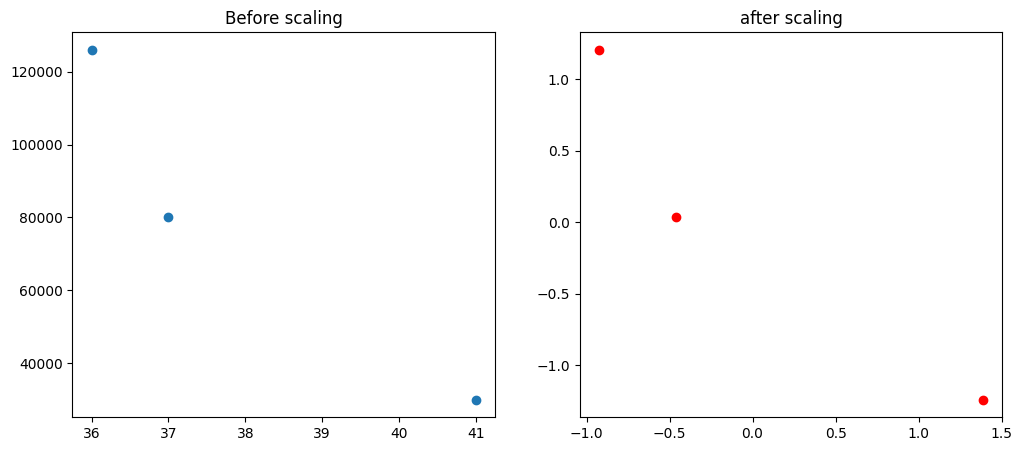

In [21]:
fig,(ax1,ax2)=plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(x_train['Age'],x_train['EstimatedSalary'])
ax1.set_title('Before scaling')
ax2.scatter(x_trained_scaled['Age'],x_trained_scaled['EstimatedSalary'],color='red')
ax2.set_title('after scaling')
plt.show()

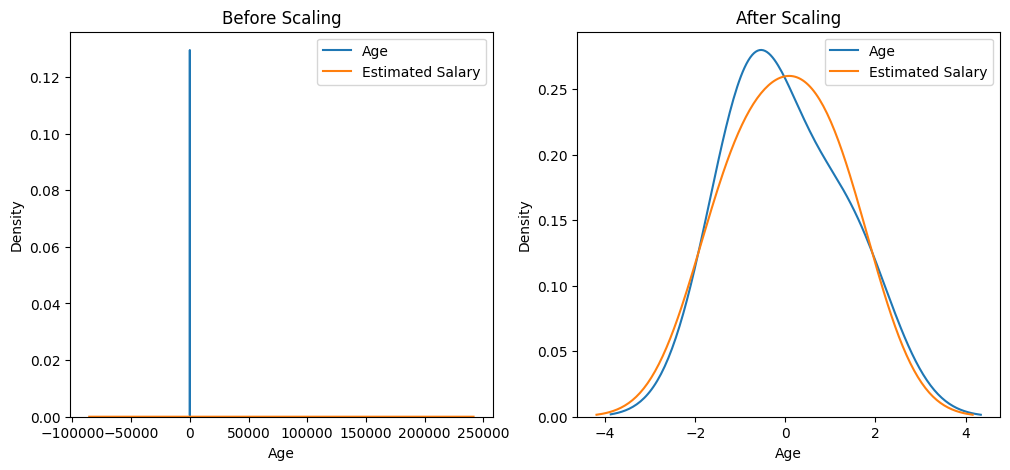

In [28]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

# Before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Age'], ax=ax1, label='Age')
sns.kdeplot(x_train['EstimatedSalary'], ax=ax1, label='Estimated Salary')
ax1.legend()

# After scaling
ax2.set_title('After Scaling')
sns.kdeplot(x_trained_scaled['Age'], ax=ax2, label='Age')
sns.kdeplot(x_trained_scaled['EstimatedSalary'], ax=ax2, label='Estimated Salary')
ax2.legend()

plt.show()

<h1>why scaling is important?</h1>

In [29]:
from sklearn.linear_model import LogisticRegression

In [31]:
lr=LogisticRegression()
lr_scaled=LogisticRegression()


In [34]:
lr.fit(x_train,y_train)
lr_scaled.fit(x_trained_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [37]:
y_pred=lr.predict(x_test)
y_pred_scaled=lr_scaled.predict(x_test_scaled)
y_pred_scaled

array([0, 0])

In [39]:
from sklearn.metrics import accuracy_score

In [40]:
print('actual',accuracy_score(y_test,y_pred))
print('scaled',accuracy_score(y_test,y_pred_scaled))

actual 1.0
scaled 1.0


In [41]:
df.describe()

,Age,EstimatedSalary,Purchased
count,5.000000,5.000000,5.000000
mean,38.600000,77600.000000,0.200000
std,2.073644,33989.704324,0.447214
min,36.000000,30000.000000,0.000000
25%,37.000000,75000.000000,0.000000
50%,39.000000,77000.000000,0.000000
75%,40.000000,80000.000000,0.000000
max,41.000000,126000.000000,1.000000
